In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/dengue_features.csv')

drop_cols = ['Date', 'District', 'Province', 'Dengue_Cases', 'Cases_log', 'Risk_Label']
feature_cols = [c for c in df.columns if c not in drop_cols]

# Encode categorical variables
categorical_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Update feature_cols after encoding
feature_cols = [c for c in df.columns if c not in drop_cols]

train = df[df['Date'] < '2021-01-01']
test  = df[df['Date'] >= '2021-01-01']

X_train = train[feature_cols]
y_train = train['Risk_Label']
X_test  = test[feature_cols]
y_test  = test['Risk_Label']

print(X_train.dtypes)

Month                    int64
Year                     int64
Temp_Max_Mean          float64
Temp_Min_Mean          float64
Temp_Mean              float64
Precipitation          float64
Rain_Sum               float64
Humidity_Proxy         float64
Windspeed_Max          float64
Latitude               float64
Longitude              float64
Temp_Mean_lag1         float64
Temp_Mean_lag2         float64
Temp_Mean_lag3         float64
Temp_Mean_lag4         float64
Rain_Sum_lag1          float64
Rain_Sum_lag2          float64
Rain_Sum_lag3          float64
Rain_Sum_lag4          float64
Humidity_Proxy_lag1    float64
Humidity_Proxy_lag2    float64
Humidity_Proxy_lag3    float64
Humidity_Proxy_lag4    float64
Rain_roll3             float64
Temp_roll3             float64
Month_sin              float64
Month_cos              float64
City_Colombo              bool
City_Galle                bool
City_Gampaha              bool
City_Hambantota           bool
City_Hatton               bool
City_Jaf

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
print("RF AUC:", roc_auc_score(y_test,rf.predict_proba(X_test)[:,1]))

RF AUC: 0.798058712121212


In [11]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
xgb.fit(X_train,y_train)
print("XGB AUC:", roc_auc_score(y_test,xgb.predict_proba(X_test)[:,1]))

XGB AUC: 0.7294428661616162


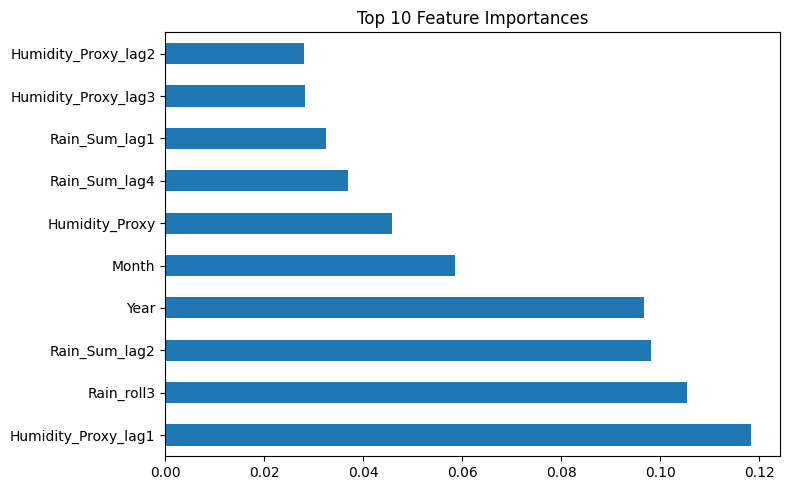

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

fi = pd.Series(xgb.feature_importances_, index =feature_cols).sort_values(ascending=False)[:10]
fi.plot(kind='barh',figsize=(8,5),title = 'Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/feature_importances.png')

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
print("XGB AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))
print(classification_report(y_test, xgb.predict(X_test)))

XGB AUC: 0.7344933712121212
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       264
           1       0.27      0.35      0.31        48

    accuracy                           0.76       312
   macro avg       0.58      0.59      0.58       312
weighted avg       0.78      0.76      0.77       312



In [14]:
import joblib
joblib.dump(rf, '../models/rf_model.pkl')

['../models/rf_model.pkl']